# 📊 สมุดบันทึกที่ 1: การสำรวจและทำความสะอาดข้อมูล (EDA & Data Cleaning)
**วิชา:** การทำเหมืองข้อมูล (Data Mining)  
**เนื้อหาอ้างอิง:** บทที่ 1 (KDD Process), บทที่ 2 (การเตรียมข้อมูล), และบทที่ 3 (EDA & Data Visualization)  
**เป้าหมาย:** สำรวจโครงสร้าง ตรวจสอบคุณภาพข้อมูล (Missing, Duplicates, Outliers), วิเคราะห์สถิติ และเตรียมคุณลักษณะก่อนสร้างโมเดลจำแนกผลการเรียน


## 1. การนำเข้าไลบรารีที่จำเป็น (Import Libraries)
อ้างอิงตามบทที่ 2 และบทที่ 3: ใช้ `pandas` จัดการข้อมูล, `numpy` คำนวณทางสถิติ, `matplotlib` และ `seaborn` สำหรับพล็อตแสดงผล


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

# กำหนดรูปแบบการแสดงผลของกราฟ
sns.set_theme(style="whitegrid")
plt.rcParams['font.family'] = 'DejaVu Sans'
print("✅ นำเข้าไลบรารีเรียบร้อย")


✅ นำเข้าไลบรารีเรียบร้อย


## 2. ขั้นตอนที่ 1: การตรวจสอบโครงสร้างข้อมูล (Data Structuring - บทที่ 3.2.1)
โหลดข้อมูลจาก `student-por.csv` (วิชาภาษาโปรตุเกส) และตรวจสอบขนาด แถว คอลัมน์ และตัวอย่างข้อมูลเบื้องต้น


In [2]:
# 1. โหลดข้อมูล (รองรับทั้ง delimiter แบบ ';' และ ',')
try:
    df = pd.read_csv('../data/student-por.csv', sep=';')
    if df.shape[1] == 1:
        df = pd.read_csv('../data/student-por.csv', sep=',')
except:
    df = pd.read_csv('../data/student-por.csv')

print(f"📊 ขนาดข้อมูล: มีทั้งหมด {df.shape[0]} แถว (นักเรียน) และ {df.shape[1]} คอลัมน์")
df.head()


📊 ขนาดข้อมูล: มีทั้งหมด 649 แถว (นักเรียน) และ 33 คอลัมน์


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,reason,guardian,traveltime,studytime,failures,schoolsup,famsup,paid,activities,nursery,higher,internet,romantic,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,course,mother,2,2,0,yes,no,no,no,yes,yes,no,no,4,3,4,1,1,3,4,0,11,11
1,GP,F,17,U,GT3,T,1,1,at_home,other,course,father,1,2,0,no,yes,no,no,no,yes,yes,no,5,3,3,1,1,3,2,9,11,11
2,GP,F,15,U,LE3,T,1,1,at_home,other,other,mother,1,2,0,yes,no,no,no,yes,yes,yes,no,4,3,2,2,3,3,6,12,13,12
3,GP,F,15,U,GT3,T,4,2,health,services,home,mother,1,3,0,no,yes,no,yes,yes,yes,yes,yes,3,2,2,1,1,5,0,14,14,14
4,GP,F,16,U,GT3,T,3,3,other,other,home,father,1,2,0,no,yes,no,no,yes,yes,no,no,4,3,2,1,2,5,0,11,13,13


### 2.1 ตรวจสอบประเภทตัวแปร (Stevens' Typology - บทที่ 2.4.1) และพจนานุกรมข้อมูล (Data Dictionary)
จำแนกประเภทตัวแปรตามมาตรวัดทางสถิติ (Nominal, Binary, Ordinal, Ratio) ครบทั้ง 33 ตัวแปร:

| ลำดับ | ชื่อตัวแปร (Feature) | คำอธิบายความหมาย (Description) | ชนิดข้อมูลสถิติ (Stevens' Typology) | ค่าที่เป็นไปได้ / สเกล (Values & Range) | บทบาทในโมเดล (Model Role) |
| :---: | :--- | :--- | :---: | :--- | :---: |
| 1 | `school` | โรงเรียนที่นักเรียนสังกัด | **Nominal (Binary)** | `GP` (Gabriel Pereira), `MS` (Mousinho da Silveira) | Feature (แปลง One-Hot) |
| 2 | `sex` | เพศของนักเรียน | **Nominal (Binary)** | `F` (หญิง), `M` (ชาย) | Feature (แปลง One-Hot) |
| 3 | `age` | อายุของนักเรียน | **Ratio (Numerical)** | 15 ถึง 22 ปี | Feature (ตัวเลขต่อเนื่อง) |
| 4 | `address` | ลักษณะพื้นที่อยู่อาศัย | **Nominal (Binary)** | `U` (ในเมือง - Urban), `R` (ชนบท - Rural) | Feature (แปลง One-Hot) |
| 5 | `famsize` | ขนาดของครอบครัว | **Nominal (Binary)** | `LE3` (<= 3 คน), `GT3` (> 3 คน) | Feature (แปลง One-Hot) |
| 6 | `Pstatus` | สถานะการอยู่ร่วมกันของบิดามารดา | **Nominal (Binary)** | `T` (อยู่ด้วยกัน - Together), `A` (แยกกันอยู่ - Apart) | Feature (แปลง One-Hot) |
| 7 | `Medu` | ระดับการศึกษาของมารดา | **Ordinal** | 0: ไม่มีการศึกษา, 1: ประถม 4, 2: ม.ต้น (ม.1–ม.3), 3: ม.ปลาย, 4: อุดมศึกษา | Feature (สเกลอันดับ 0–4) |
| 8 | `Fedu` | ระดับการศึกษาของบิดา | **Ordinal** | 0: ไม่มีการศึกษา, 1: ประถม 4, 2: ม.ต้น (ม.1–ม.3), 3: ม.ปลาย, 4: อุดมศึกษา | Feature (สเกลอันดับ 0–4) |
| 9 | `Mjob` | อาชีพของมารดา | **Nominal** | `teacher` (ครู), `health` (สาธารณสุข), `services` (ข้าราชการ/บริการ), `at_home` (แม่บ้าน), `other` (อื่นๆ) | Feature (แปลง One-Hot) |
| 10 | `Fjob` | อาชีพของบิดา | **Nominal** | `teacher`, `health`, `services`, `at_home`, `other` | Feature (แปลง One-Hot) |
| 11 | `reason` | เหตุผลในการเลือกเข้าเรียนที่โรงเรียนนี้ | **Nominal** | `home` (ใกล้บ้าน), `reputation` (ชื่อเสียงโรงเรียน), `course` (หลักสูตรตรงใจ), `other` (อื่นๆ) | Feature (แปลง One-Hot) |
| 12 | `guardian` | ผู้ปกครองหลักที่ดูแลนักเรียน | **Nominal** | `mother` (แม่), `father` (พ่อ), `other` (คนอื่น) | Feature (แปลง One-Hot) |
| 13 | `traveltime` | ระยะเวลาเดินทางจากบ้านไปโรงเรียน | **Ordinal** | 1: <15 นาที, 2: 15–30 นาที, 3: 30 นาที – 1 ชม., 4: >1 ชม. | Feature (สเกลอันดับ 1–4) |
| 14 | `studytime` | เวลาทบทวนบทเรียนนอกเวลาต่อสัปดาห์ | **Ordinal** | 1: <2 ชม., 2: 2–5 ชม., 3: 5–10 ชม., 4: >10 ชม. | Feature (สเกลอันดับ 1–4) |
| 15 | `failures` | จำนวนวิชาที่เคยสอบตกสะสมในอดีต | **Ratio (Discrete Count)** | 0, 1, 2, 3 (หาก >= 3 ครั้งจะถูกนับเป็น 3) | Feature (ตัวเลขจำนวนนับ) |
| 16 | `schoolsup` | การได้รับความช่วยเหลือทางการเรียนพิเศษจากโรงเรียน | **Nominal (Binary)** | `yes` (ได้รับ), `no` (ไม่ได้รับ) | Feature (แปลง One-Hot) |
| 17 | `famsup` | การได้รับการสนับสนุนการเรียนจากครอบครัว | **Nominal (Binary)** | `yes` (ได้รับ), `no` (ไม่ได้รับ) | Feature (แปลง One-Hot) |
| 18 | `paid` | การเรียนพิเศษกวดวิชาแบบเสียเงินในวิชานี้ | **Nominal (Binary)** | `yes` (เรียน), `no` (ไม่เรียน) | Feature (แปลง One-Hot) |
| 19 | `activities` | การเข้าร่วมกิจกรรมนอกหลักสูตร/ชมรม | **Nominal (Binary)** | `yes` (เข้าร่วม), `no` (ไม่เข้าร่วม) | Feature (แปลง One-Hot) |
| 20 | `nursery` | การเคยเข้าเรียนในระดับชั้นอนุบาล | **Nominal (Binary)** | `yes` (เคย), `no` (ไม่เคย) | Feature (แปลง One-Hot) |
| 21 | `higher` | ความตั้งใจจะศึกษาต่อระดับมหาวิทยาลัย | **Nominal (Binary)** | `yes` (ต้องการเรียนต่อ), `no` (ไม่ต้องการ) | Feature (แปลง One-Hot) |
| 22 | `internet` | การมีสัญญาณอินเทอร์เน็ตที่บ้าน | **Nominal (Binary)** | `yes` (มี), `no` (ไม่มี) | Feature (แปลง One-Hot) |
| 23 | `romantic` | การมีความสัมพันธ์เชิงชู้สาว (มีแฟน) | **Nominal (Binary)** | `yes` (มี), `no` (ไม่มี) | Feature (แปลง One-Hot) |
| 24 | `famrel` | คุณภาพความสัมพันธ์ภายในครอบครัว | **Ordinal** | 1: แย่มาก ถึง 5: ดีเยี่ยม | Feature (สเกลประเมิน 1–5) |
| 25 | `freetime` | เวลาว่างหลังเลิกเรียน | **Ordinal** | 1: น้อยมาก ถึง 5: มากที่สุด | Feature (สเกลประเมิน 1–5) |
| 26 | `goout` | ความถี่ในการออกไปสังสรรค์กับเพื่อน | **Ordinal** | 1: น้อยมาก ถึง 5: บ่อยมาก | Feature (สเกลประเมิน 1–5) |
| 27 | `Dalc` | การดื่มแอลกอฮอล์ในวันธรรมดา (จันทร์–ศุกร์) | **Ordinal** | 1: น้อยมาก ถึง 5: หนักมาก | Feature (สเกลประเมิน 1–5) |
| 28 | `Walc` | การดื่มแอลกอฮอล์ในวันหยุดสุดสัปดาห์ (เสาร์–อาทิตย์) | **Ordinal** | 1: น้อยมาก ถึง 5: หนักมาก | Feature (สเกลประเมิน 1–5) |
| 29 | `health` | สถานะสุขภาพร่างกายในปัจจุบัน | **Ordinal** | 1: แย่มาก ถึง 5: แข็งแรงสมบูรณ์มาก | Feature (สเกลประเมิน 1–5) |
| 30 | `absences` | จำนวนครั้งที่ขาดเรียนสะสมตลอดปี | **Ratio (Numerical)** | 0 ถึง 32 ครั้ง (ใน student-por) | Feature (ตัวเลขต่อเนื่อง) |
| 31 | `G1` | เกรดประเมินผลภาคเรียนที่ 1 | **Ratio (0–20)** | 0 ถึง 20 คะแนน | ⚠️ **ตัดทิ้ง (Drop: ป้องกัน Data Leakage)** |
| 32 | `G2` | เกรดประเมินผลภาคเรียนที่ 2 | **Ratio (0–20)** | 0 ถึง 20 คะแนน | ⚠️ **ตัดทิ้ง (Drop: ป้องกัน Data Leakage)** |
| 33 | `G3` | เกรดประเมินรวบยอดปลายปีการศึกษา | **Ratio (0–20)** | 0 ถึง 20 คะแนน | 🎯 **นำไปสร้าง Target แล้วตัดทิ้ง** |
| - | `passed` | สถานะการสอบผ่านตามเกณฑ์กระทรวงศึกษาธิการโปรตุเกส | **Binary Target** | `1` (ผ่าน: G3 >= 10), `0` (ตก: G3 < 10) | 🏆 **ตัวแปรเป้าหมาย (Target y)** |


In [3]:
# ตรวจสอบ Data Type และ Non-Null Count
print("=" * 60)
print("📋 โครงสร้างและชนิดของตัวแปร (Data Types):")
print("=" * 60)
df.info()


📋 โครงสร้างและชนิดของตัวแปร (Data Types):
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 649 entries, 0 to 648
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   school      649 non-null    object
 1   sex         649 non-null    object
 2   age         649 non-null    int64 
 3   address     649 non-null    object
 4   famsize     649 non-null    object
 5   Pstatus     649 non-null    object
 6   Medu        649 non-null    int64 
 7   Fedu        649 non-null    int64 
 8   Mjob        649 non-null    object
 9   Fjob        649 non-null    object
 10  reason      649 non-null    object
 11  guardian    649 non-null    object
 12  traveltime  649 non-null    int64 
 13  studytime   649 non-null    int64 
 14  failures    649 non-null    int64 
 15  schoolsup   649 non-null    object
 16  famsup      649 non-null    object
 17  paid        649 non-null    object
 18  activities  649 non-null    object
 19  nursery 

In [4]:
# แสดงสถิติเชิงพรรณนาสำหรับตัวแปรเชิงปริมาณ
df.describe()


,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
count,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000
mean,16.744222,2.514638,2.306626,1.568567,1.930663,0.221880,3.930663,3.180277,3.184900,1.502311,2.280431,3.536210,3.659476,11.399076,11.570108,11.906009
std,1.218138,1.134552,1.099931,0.748660,0.829510,0.593235,0.955717,1.051093,1.175766,0.924834,1.284380,1.446259,4.640759,2.745265,2.913639,3.230656
min,15.000000,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,16.000000,2.000000,1.000000,1.000000,1.000000,0.000000,4.000000,3.000000,2.000000,1.000000,1.000000,2.000000,0.000000,10.000000,10.000000,10.000000
50%,17.000000,2.000000,2.000000,1.000000,2.000000,0.000000,4.000000,3.000000,3.000000,1.000000,2.000000,4.000000,2.000000,11.000000,11.000000,12.000000
75%,18.000000,4.000000,3.000000,2.000000,2.000000,0.000000,5.000000,4.000000,4.000000,2.000000,3.000000,5.000000,6.000000,13.000000,13.000000,14.000000
max,22.000000,4.000000,4.000000,4.000000,4.000000,3.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,32.000000,19.000000,19.000000,19.000000


## 3. ขั้นตอนที่ 2: การทำความสะอาดข้อมูล (Data Cleaning - บทที่ 2.6 & 3.2 ขั้นที่ 2)

### 3.1 ตรวจสอบข้อมูลสูญหาย (Missing Values - บทที่ 2.6.2)
ตรวจสอบว่ามีข้อมูลสูญหายหรือไม่ และเข้าข่ายประเภทใด (MCAR, MAR, MNAR)


In [5]:
# ตรวจสอบจำนวน Missing Values ในแต่ละคอลัมน์
missing_count = df.isnull().sum()
total_missing = missing_count.sum()

print(f"🔍 จำนวน Missing Values ทั้งหมดในชุดข้อมูล: {total_missing} ค่า")
if total_missing == 0:
    print("✨ ข้อมูลมีความสมบูรณ์แบบ 100% ไม่จำเป็นต้องทำ Data Imputation")
else:
    print(missing_count[missing_count > 0])


🔍 จำนวน Missing Values ทั้งหมดในชุดข้อมูล: 0 ค่า
✨ ข้อมูลมีความสมบูรณ์แบบ 100% ไม่จำเป็นต้องทำ Data Imputation


### 3.2 ตรวจสอบข้อมูลซ้ำซ้อน (Duplicate Data - บทที่ 2.6.3)


In [6]:
# ตรวจสอบแถวที่ซ้ำกัน
duplicate_count = df.duplicated().sum()
print(f"🔍 จำนวนแถวที่ซ้ำซ้อน: {duplicate_count} แถว")
if duplicate_count == 0:
    print("✨ ไม่พบข้อมูลซ้ำซ้อนในชุดข้อมูล")


🔍 จำนวนแถวที่ซ้ำซ้อน: 0 แถว
✨ ไม่พบข้อมูลซ้ำซ้อนในชุดข้อมูล


### 3.3 การตรวจจับและจัดการค่าผิดปกติ (Outlier Detection ด้วยวิธี IQR - บทที่ 2.6.1)
ตามบทที่ 2.6.1 กำหนดให้ใช้สูตร Interquartile Range (IQR):
$$IQR = Q_3 - Q_1$$
$$	ext{Lower Bound} = Q_1 - 1.5 	imes IQR \quad , \quad 	ext{Upper Bound} = Q_3 + 1.5 	imes IQR$$


In [7]:
# ฟังก์ชันตรวจจับ Outlier ด้วย IQR Method ตามบทที่ 2.6.1
def detect_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = data[(data[column] < lower_bound) | (data[column] > upper_bound)]
    return len(outliers), lower_bound, upper_bound

# ตรวจสอบตัวแปรเชิงตัวเลขสำคัญ
numeric_features = ['age', 'absences', 'failures', 'G3']
print("📊 ผลการตรวจสอบ Outliers ด้วยวิธี IQR:")
print("-" * 65)
for col in numeric_features:
    count, low, up = detect_outliers_iqr(df, col)
    print(f"• {col:<10}: พบ {count:>3} ค่า | ช่วงปกติ [{low:>5.1f}, {up:>5.1f}] | ต่ำสุด-สูงสุด [{df[col].min()}, {df[col].max()}]")


📊 ผลการตรวจสอบ Outliers ด้วยวิธี IQR:
-----------------------------------------------------------------
• age       : พบ   1 ค่า | ช่วงปกติ [ 13.0,  21.0] | ต่ำสุด-สูงสุด [15, 22]
• absences  : พบ  21 ค่า | ช่วงปกติ [ -9.0,  15.0] | ต่ำสุด-สูงสุด [0, 32]
• failures  : พบ 100 ค่า | ช่วงปกติ [  0.0,   0.0] | ต่ำสุด-สูงสุด [0, 3]
• G3        : พบ  16 ค่า | ช่วงปกติ [  4.0,  20.0] | ต่ำสุด-สูงสุด [0, 19]


#### 💡 การตัดสินใจเชิงวิเคราะห์เรื่อง Outlier และการเจาะลึกกรณี `absences` (สำคัญมาก!):

##### 1. ทำไมช่วงปกติของ `absences` ถึงเป็น `[-9.0, 15.0]`? ค่าติดลบ `-9.0` คืออะไร?
* **การคำนวณทางคณิตศาสตร์ตามสูตร IQR (บทที่ 2.6.1):**
  * $Q_1$ (ควอร์ไทล์ที่ 1 / เปอร์เซ็นไทล์ที่ 25) = **$0.0$** (เนื่องจากมีนักเรียนถึง 244 คน หรือ **37.6%** ไม่เคยขาดเรียนเลย ข้อมูลจึงกระจุกตัวที่ 0 ทำให้ $Q_1 = 0$ โดยปริยาย)
  * $Q_2$ (มัธยฐาน / Median) = **$2.0$ วัน**
  * $Q_3$ (ควอร์ไทล์ที่ 3 / เปอร์เซ็นไทล์ที่ 75) = **$6.0$ วัน**
  * ค่าพิสัยระหว่างควอร์ไทล์: $IQR = Q_3 - Q_1 = 6.0 - 0.0 = 6.0$ วัน
  * **ขอบล่างตามสูตรสถิติ (Theoretical Lower Bound):**  
    $$\text{Lower Bound} = Q_1 - 1.5 \times IQR = 0.0 - (1.5 \times 6.0) = 0.0 - 9.0 = \mathbf{-9.0 \text{ วัน}}$$
  * **ขอบบนตามสูตรสถิติ (Upper Bound):**  
    $$\text{Upper Bound} = Q_3 + 1.5 \times IQR = 6.0 + (1.5 \times 6.0) = 6.0 + 9.0 = \mathbf{15.0 \text{ วัน}}$$

* **ข้อจำกัดทางกายภาพในโลกความเป็นจริง (Domain Knowledge vs Theoretical Bound):**
  * ตาม **Stevens' Typology (บทที่ 2.4.1)** ตัวแปร `absences` เป็นข้อมูลแบบ **Ratio Scale (มาตรวัดอัตราส่วน)** ที่มี *ศูนย์แท้ (Absolute Zero)* ค่าของวันขาดเรียนไม่สามารถติดลบได้ในความเป็นจริง ($x \ge 0$)
  * สูตร IQR เป็นเพียงสมการทางสถิติแบบสมมาตร (Symmetric statistical fence) ที่ลากเส้นถอยหลังจาก $Q_1$ ลงไปตามระยะ $1.5 \times IQR$ โดยไม่ได้คำนึงถึงธรรมชาติของข้อมูล
  * ดังนั้น **ขอบล่างจริงตามธรรมชาติ (Natural Lower Bound) จึงอยู่ที่ 0 วัน**
  * ส่วนช่วง $[-9.0, 0)$ จัดเป็น **"โซนที่เป็นไปไม่ได้ในทางปฏิบัติ (Physically Impossible Zone)"**
  * ขอบเขตปกติที่ใช้งานได้จริง (Effective Practical Range) จึงเท่ากับ **$[0, 15.0]$ วัน**

##### 2. Outliers ทั้ง 21 คน อยู่ที่ไหน?
* เนื่องจากไม่มีนักเรียนคนใดขาดเรียนน้อยกว่า 0 วัน $\rightarrow$ **ไม่มี Outlier ฝั่งค่าต่ำเลยแม้แต่คนเดียว (0 คน)**
* Outliers ทั้งหมด 21 คน **เกิดขึ้นที่ฝั่งขอบบน (Upper Bound $> 15.0$ วัน) ล้วนๆ 100%!**
* นักเรียน 21 คนนี้ มีวันขาดเรียนจริงตั้งแต่ **16, 18, 21, 22, 24, 26, 30, ไปจนถึงสูงสุด 32 วัน** (คิดเป็น 3.24% ของนักเรียนทั้งหมด)

##### 3. ทำไมถึง "ห้ามลบ Outliers 21 คนนี้ทิ้งเด็ดขาด"? (Data Mining & Early Warning Rationale):
* **ไม่ใช่ข้อมูลกรอกผิด (Not Noise/Entry Error):** ในรอบ 1 ปีการศึกษา (ประมาณ 200 วันทำการ) การที่เด็กจะขาดเรียนสะสม 16–32 วัน เป็นเหตุการณ์ที่เกิดขึ้นได้จริงในชีวิตจริง
* **เป็นกลุ่มเสี่ยงวิกฤต (Target Minority):** พฤติกรรม *"ขาดเรียนเรื้อรัง (Chronic Absenteeism)"* คือหนึ่งในสัญญาณบ่งชี้ความเสี่ยงที่จะสอบตกที่สำคัญที่สุดในงานวิจัยทางการศึกษา
* **หากลบทิ้ง โมเดลจะพิการ:** หากตัดข้อมูลเด็ก 21 คนนี้ทิ้ง โมเดลจะไม่เคยเห็นพฤติกรรมของนักเรียนที่ขาดเรียนหนักๆ ส่งผลให้ระบบ Early Warning ไม่สามารถแจ้งเตือนเด็กกลุ่มเสี่ยงวิกฤตได้


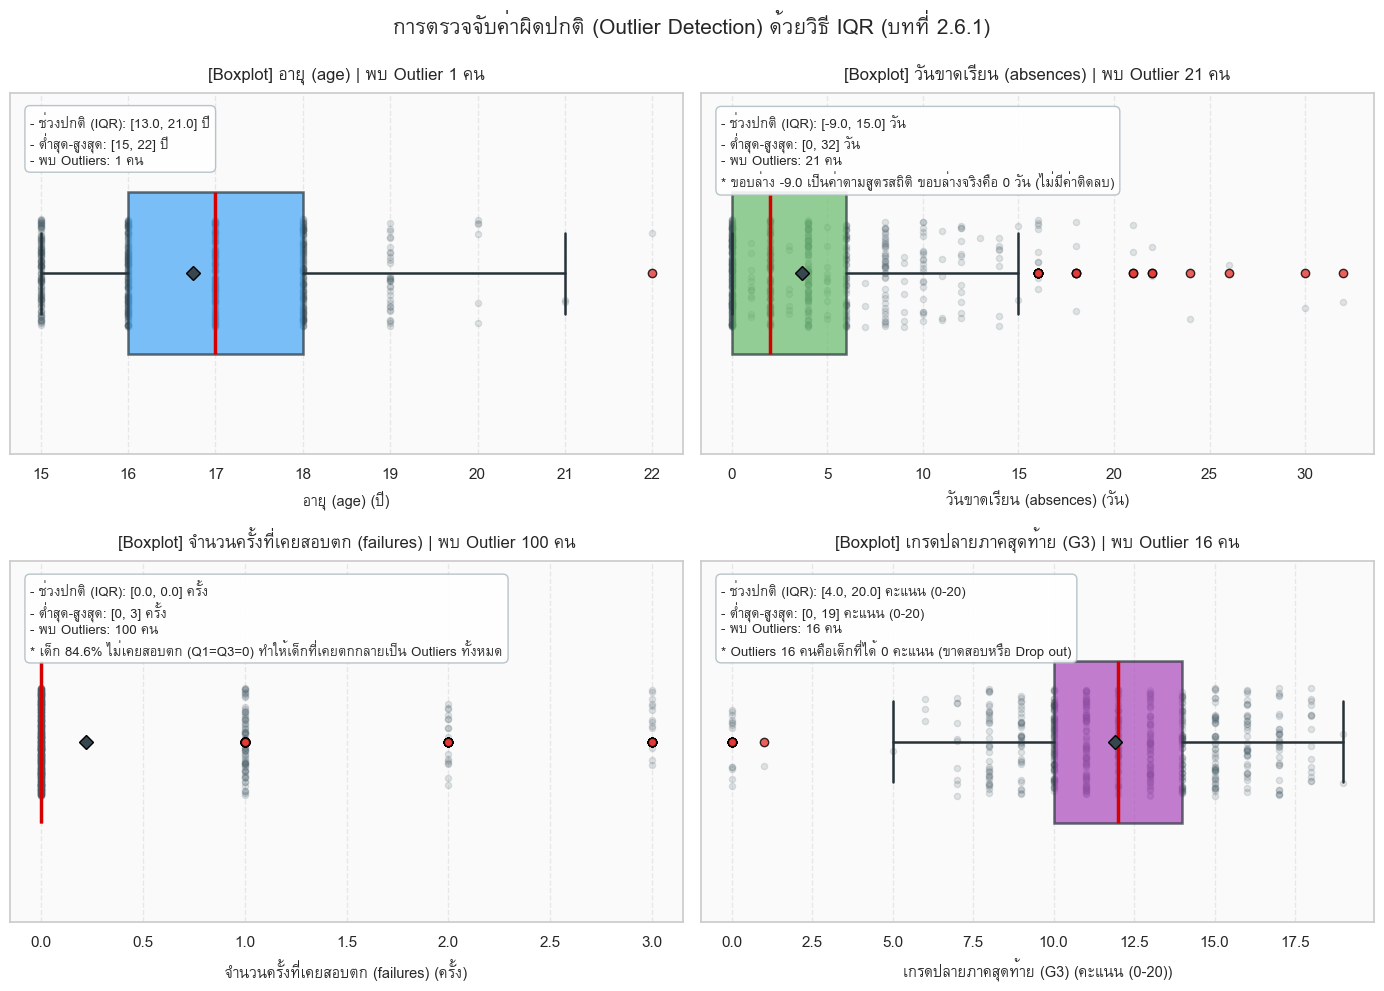

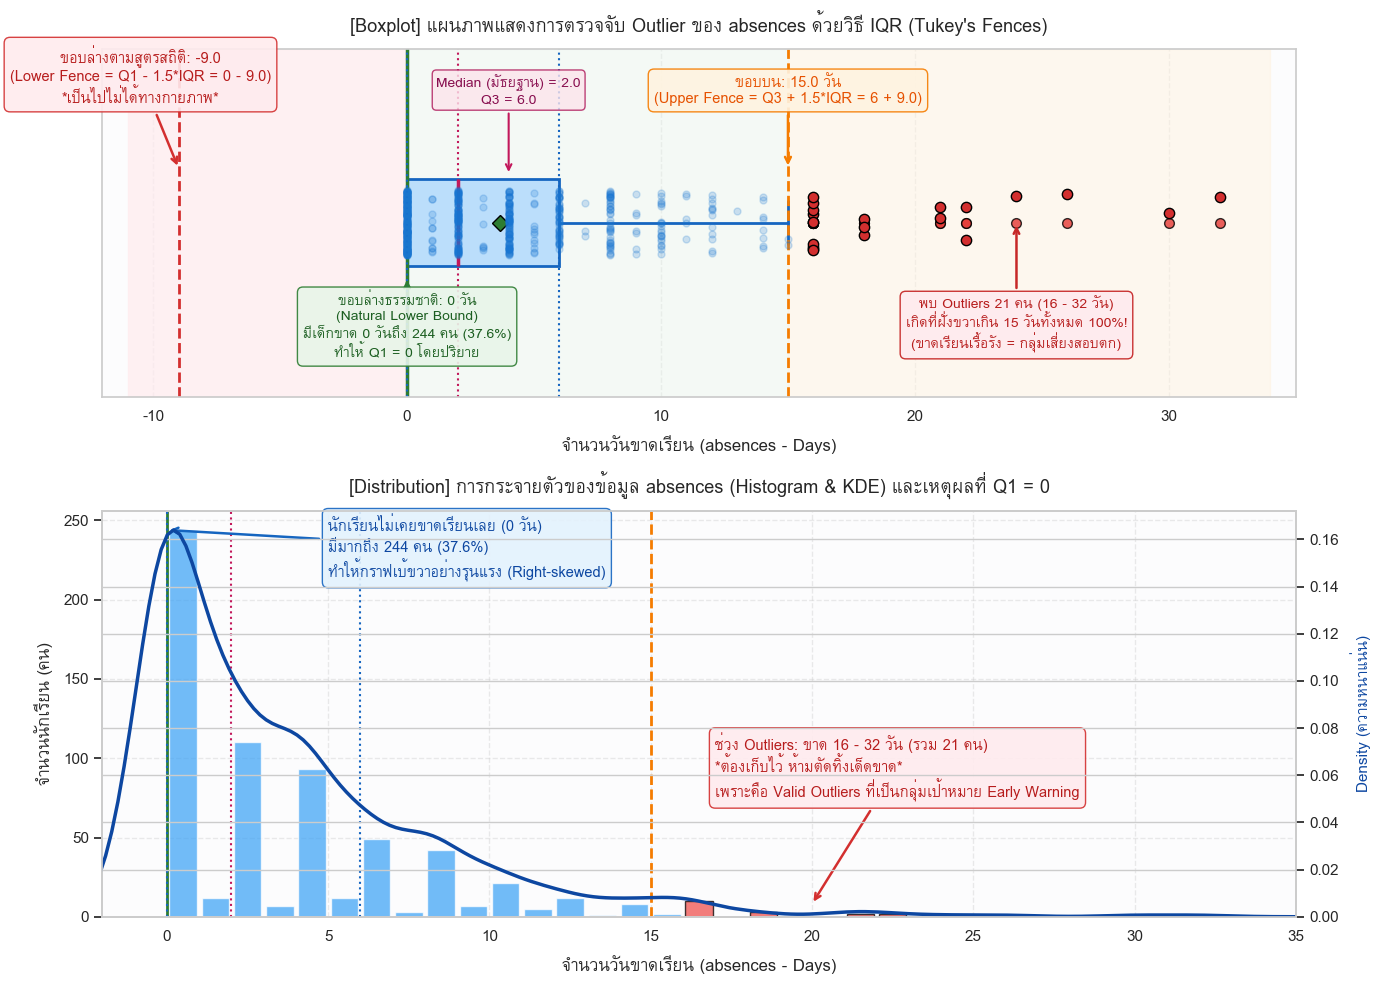

In [8]:
# พล็อตแผนภาพการตรวจจับ Outliers (บทที่ 2.6.1) และเจาะลึกกรณีตัวแปร absences
import os
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns
import numpy as np

# ตั้งค่าฟอนต์ภาษาไทย (Garuda)
font_path = '/usr/share/fonts/truetype/tlwg/Garuda.ttf'
if os.path.exists(font_path):
    fm.fontManager.addfont(font_path)
    prop = fm.FontProperties(fname=font_path)
    plt.rcParams['font.family'] = prop.get_name()
plt.rcParams['axes.unicode_minus'] = False

# -------------------------------------------------------------
# กราฟที่ 1: แผนภาพ Boxplot รวม 4 ตัวแปรตัวเลขสำคัญ (Overview)
# -------------------------------------------------------------
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.patch.set_facecolor('#ffffff')
features_info = [
    ('age', 'อายุ (age)', 'ปี', '#42a5f5', 1, [13.0, 21.0]),
    ('absences', 'วันขาดเรียน (absences)', 'วัน', '#66bb6a', 21, [-9.0, 15.0]),
    ('failures', 'จำนวนครั้งที่เคยสอบตก (failures)', 'ครั้ง', '#ffa726', 100, [0.0, 0.0]),
    ('G3', 'เกรดปลายภาคสุดท้าย (G3)', 'คะแนน (0-20)', '#ab47bc', 16, [4.0, 20.0])
]
for idx, (col, title, unit, color, out_cnt, bounds) in enumerate(features_info):
    ax = axes[idx // 2, idx % 2]
    ax.set_facecolor('#fafafa')
    bp = ax.boxplot(df[col], vert=False, positions=[1], widths=0.45,
                    patch_artist=True, showmeans=True,
                    meanprops=dict(marker='D', markeredgecolor='black', markerfacecolor='#37474f', markersize=7),
                    boxprops=dict(facecolor=color, color='#263238', linewidth=1.8, alpha=0.7),
                    whiskerprops=dict(color='#263238', linewidth=1.8),
                    capprops=dict(color='#263238', linewidth=1.8),
                    medianprops=dict(color='#d50000', linewidth=2.5),
                    flierprops=dict(marker='o', markerfacecolor='#e53935', markeredgecolor='black', markersize=6, alpha=0.8))
    np.random.seed(idx)
    y_jit = 1 + np.random.uniform(-0.15, 0.15, size=len(df))
    ax.scatter(df[col], y_jit, color='#455a64', alpha=0.15, s=20)
    special_note = ''
    if col == 'absences':
        special_note = '\n* ขอบล่าง -9.0 เป็นค่าตามสูตรสถิติ ขอบล่างจริงคือ 0 วัน (ไม่มีค่าติดลบ)'
    elif col == 'failures':
        special_note = '\n* เด็ก 84.6% ไม่เคยสอบตก (Q1=Q3=0) ทำให้เด็กที่เคยตกกลายเป็น Outliers ทั้งหมด'
    elif col == 'G3':
        special_note = '\n* Outliers 16 คนคือเด็กที่ได้ 0 คะแนน (ขาดสอบหรือ Drop out)'
    summary_text = f"- ช่วงปกติ (IQR): [{bounds[0]:.1f}, {bounds[1]:.1f}] {unit}\n- ต่ำสุด-สูงสุด: [{df[col].min()}, {df[col].max()}] {unit}\n- พบ Outliers: {out_cnt} คน" + special_note
    ax.text(0.03, 0.95, summary_text, transform=ax.transAxes, verticalalignment='top', fontsize=9.5,
            bbox=dict(boxstyle='round,pad=0.4', facecolor='white', edgecolor='#b0bec5', alpha=0.9))
    ax.set_title(f"[Boxplot] {title} | พบ Outlier {out_cnt} คน", fontsize=12, fontweight='bold', pad=10)
    ax.set_xlabel(f"{title} ({unit})", fontsize=10.5, labelpad=6)
    ax.set_yticks([])
    ax.set_ylim(0.5, 1.5)
    ax.grid(True, linestyle='--', alpha=0.4, axis='x')
plt.suptitle('การตรวจจับค่าผิดปกติ (Outlier Detection) ด้วยวิธี IQR (บทที่ 2.6.1)', fontsize=15, fontweight='bold', y=0.99)
plt.tight_layout()
os.makedirs('../images', exist_ok=True)
plt.savefig('../images/outliers_boxplot.png', dpi=300, bbox_inches='tight')
plt.show()

# -------------------------------------------------------------
# กราฟที่ 2: เจาะลึกตัวแปร absences พร้อมอธิบายที่มาของ -9.0
# -------------------------------------------------------------
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10), gridspec_kw={'height_ratios': [1.2, 1.4]})
fig.patch.set_facecolor('#ffffff')
q1 = df['absences'].quantile(0.25)
q2 = df['absences'].median()
q3 = df['absences'].quantile(0.75)
iqr = q3 - q1
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr
zero_count = (df['absences'] == 0).sum()
zero_pct = (df['absences'] == 0).mean() * 100

# Panel 1: Boxplot
ax1.set_facecolor('#fcfcfd')
ax1.axvspan(-11, 0, color='#ffebee', alpha=0.7, label='Impossible Region (< 0 วัน)')
ax1.axvspan(0, upper_bound, color='#e8f5e9', alpha=0.4, label='Normal Range จริง [0, 15 วัน]')
ax1.axvspan(upper_bound, 34, color='#fff3e0', alpha=0.5, label='Outlier Zone (> 15 วัน)')
ax1.boxplot(df['absences'], vert=False, positions=[1], widths=0.4, patch_artist=True, showmeans=True,
            meanprops=dict(marker='D', markeredgecolor='black', markerfacecolor='#2e7d32', markersize=8),
            boxprops=dict(facecolor='#bbdefb', color='#1565c0', linewidth=2),
            whiskerprops=dict(color='#1565c0', linewidth=2),
            capprops=dict(color='#1565c0', linewidth=2),
            medianprops=dict(color='#c2185b', linewidth=2.5),
            flierprops=dict(marker='o', markerfacecolor='#e53935', markeredgecolor='black', markersize=7, alpha=0.8))
np.random.seed(42)
y_jitter = 1 + np.random.uniform(-0.15, 0.15, size=len(df))
normal_mask = df['absences'] <= upper_bound
ax1.scatter(df.loc[normal_mask, 'absences'], y_jitter[normal_mask], color='#1976d2', alpha=0.2, s=25, zorder=3)
ax1.scatter(df.loc[~normal_mask, 'absences'], y_jitter[~normal_mask], color='#d32f2f', edgecolor='black', s=55, zorder=4)
ax1.axvline(lower_bound, color='#d32f2f', linestyle='--', linewidth=2)
ax1.axvline(0, color='#2e7d32', linestyle='-', linewidth=2.5)
ax1.axvline(q1, color='#1565c0', linestyle=':', linewidth=1.5)
ax1.axvline(q2, color='#c2185b', linestyle=':', linewidth=1.5)
ax1.axvline(q3, color='#1565c0', linestyle=':', linewidth=1.5)
ax1.axvline(upper_bound, color='#f57c00', linestyle='--', linewidth=2)
ax1.annotate(f'ขอบล่างตามสูตรสถิติ: -9.0\n(Lower Fence = Q1 - 1.5*IQR = 0 - 9.0)\n*เป็นไปไม่ได้ทางกายภาพ*',
             xy=(lower_bound, 1.25), xytext=(lower_bound - 1.5, 1.55),
             arrowprops=dict(arrowstyle='->', color='#d32f2f', lw=1.8),
             fontsize=10.5, fontweight='bold', color='#b71c1c', ha='center',
             bbox=dict(boxstyle='round,pad=0.4', facecolor='#ffebee', edgecolor='#d32f2f', alpha=0.9))
ax1.annotate(f'ขอบล่างธรรมชาติ: 0 วัน\n(Natural Lower Bound)\nมีเด็กขาด 0 วันถึง {zero_count} คน ({zero_pct:.1f}%)\nทำให้ Q1 = 0 โดยปริยาย',
             xy=(0, 0.75), xytext=(0, 0.38),
             arrowprops=dict(arrowstyle='->', color='#2e7d32', lw=1.8),
             fontsize=10, fontweight='bold', color='#1b5e20', ha='center',
             bbox=dict(boxstyle='round,pad=0.4', facecolor='#e8f5e9', edgecolor='#2e7d32', alpha=0.9))
ax1.annotate(f'Median (มัธยฐาน) = 2.0\nQ3 = 6.0', xy=(4, 1.22), xytext=(4, 1.55),
             arrowprops=dict(arrowstyle='->', color='#c2185b', lw=1.5),
             fontsize=10, color='#880e4f', ha='center',
             bbox=dict(boxstyle='round,pad=0.3', facecolor='#fce4ec', edgecolor='#ad1457', alpha=0.8))
ax1.annotate(f'ขอบบน: 15.0 วัน\n(Upper Fence = Q3 + 1.5*IQR = 6 + 9.0)', xy=(upper_bound, 1.25), xytext=(upper_bound, 1.55),
             arrowprops=dict(arrowstyle='->', color='#f57c00', lw=1.8),
             fontsize=10.5, fontweight='bold', color='#e65100', ha='center',
             bbox=dict(boxstyle='round,pad=0.4', facecolor='#fff3e0', edgecolor='#f57c00', alpha=0.9))
ax1.annotate(f'พบ Outliers 21 คน (16 - 32 วัน)\nเกิดที่ฝั่งขวาเกิน 15 วันทั้งหมด 100%!\n(ขาดเรียนเรื้อรัง = กลุ่มเสี่ยงสอบตก)',
             xy=(24, 1.0), xytext=(24, 0.42),
             arrowprops=dict(arrowstyle='->', color='#c62828', lw=1.8),
             fontsize=10, fontweight='bold', color='#b71c1c', ha='center',
             bbox=dict(boxstyle='round,pad=0.4', facecolor='#ffebee', edgecolor='#c62828', alpha=0.95))
ax1.set_xlim(-12, 35)
ax1.set_ylim(0.2, 1.8)
ax1.set_yticks([])
ax1.set_xlabel('จำนวนวันขาดเรียน (absences - Days)', fontsize=12, fontweight='bold', labelpad=8)
ax1.set_title('[Boxplot] แผนภาพแสดงการตรวจจับ Outlier ของ absences ด้วยวิธี IQR (Tukey\'s Fences)', fontsize=13, fontweight='bold', pad=12)
ax1.grid(True, linestyle='--', alpha=0.4, axis='x')

# Panel 2: Distribution
ax2.set_facecolor('#fcfcfd')
bins = np.arange(0, 34, 1)
n, _, patches = ax2.hist(df['absences'], bins=bins, color='#42a5f5', edgecolor='white', alpha=0.75, rwidth=0.85)
for i in range(len(patches)):
    if bins[i] > 15:
        patches[i].set_facecolor('#ef5350')
        patches[i].set_edgecolor('black')
ax2_twin = ax2.twinx()
sns.kdeplot(df['absences'], ax=ax2_twin, color='#0d47a1', linewidth=2.5, bw_adjust=0.8)
ax2_twin.set_ylabel('Density (ความหนาแน่น)', fontsize=11, color='#0d47a1', labelpad=8)
ax2_twin.set_ylim(bottom=0)
ax2.axvline(0, color='#2e7d32', linestyle='-', linewidth=2)
ax2.axvline(q1, color='#1565c0', linestyle=':', linewidth=1.5)
ax2.axvline(q2, color='#c2185b', linestyle=':', linewidth=1.5)
ax2.axvline(q3, color='#1565c0', linestyle=':', linewidth=1.5)
ax2.axvline(upper_bound, color='#f57c00', linestyle='--', linewidth=2)
ax2.annotate(f'นักเรียนไม่เคยขาดเรียนเลย (0 วัน)\nมีมากถึง {zero_count} คน ({zero_pct:.1f}%)\nทำให้กราฟเบ้ขวาอย่างรุนแรง (Right-skewed)',
             xy=(0, zero_count), xytext=(5, zero_count - 30),
             arrowprops=dict(arrowstyle='->', color='#1565c0', lw=1.8),
             fontsize=10.5, fontweight='bold', color='#0d47a1',
             bbox=dict(boxstyle='round,pad=0.4', facecolor='#e3f2fd', edgecolor='#1565c0', alpha=0.9))
ax2.annotate(f'ช่วง Outliers: ขาด 16 - 32 วัน (รวม 21 คน)\n*ต้องเก็บไว้ ห้ามตัดทิ้งเด็ดขาด*\nเพราะคือ Valid Outliers ที่เป็นกลุ่มเป้าหมาย Early Warning',
             xy=(20, 8), xytext=(17, 75),
             arrowprops=dict(arrowstyle='->', color='#d32f2f', lw=1.8),
             fontsize=10.5, fontweight='bold', color='#b71c1c',
             bbox=dict(boxstyle='round,pad=0.4', facecolor='#ffebee', edgecolor='#d32f2f', alpha=0.9))
ax2.set_xlim(-2, 35)
ax2.set_xlabel('จำนวนวันขาดเรียน (absences - Days)', fontsize=12, fontweight='bold', labelpad=8)
ax2.set_ylabel('จำนวนนักเรียน (คน)', fontsize=12, fontweight='bold', labelpad=8)
ax2.set_title('[Distribution] การกระจายตัวของข้อมูล absences (Histogram & KDE) และเหตุผลที่ Q1 = 0', fontsize=13, fontweight='bold', pad=12)
ax2.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig('../images/absences_iqr_explanation.png', dpi=300, bbox_inches='tight')
plt.show()


## 4. ขั้นตอนที่ 3: การสำรวจข้อมูลเชิงตัวแปรเดี่ยว (Univariate Analysis - บทที่ 3.2 ขั้นที่ 3)

### 4.1 บริบทการประเมินผลตามระบบการศึกษาโปรตุเกส (Portuguese 0-20 Scale)
ตามระบบการศึกษาของประเทศโปรตุเกส (*Ensino Secundário*) ในระดับมัธยมปลาย:
* **สเกลคะแนนเต็ม 20 (ไม่ใช่เต็ม 100):** การวัดผลใช้ช่วงคะแนน **0 ถึง 20 คะแนน** โดยมีเกณฑ์ผ่านขั้นต่ำคือ **10 คะแนน (คิดเป็น 50%)**
* **วิชาภาษาโปรตุเกส (*Português*):** ข้อมูลชุดนี้คือผลการเรียนในวิชาภาษาโปรตุเกส ซึ่งเป็นวิชาบังคับหลักรายปี (Annual Subject) ไม่ใช่เกรดเฉลี่ยสะสม (GPA)
* **ระบบ 3 ภาคเรียน (Trimesters: G1, G2, G3):**
  * `G1` (เทอม 1 : ก.ย.-ธ.ค.) และ `G2` (เทอม 2 : ม.ค.-เม.ย.) คือเกรดวัดผลระหว่างทาง (Interim Progress Grades)
  * `G3` (เทอม 3 : เม.ย.-มิ.ย.) คือ **เกรดตัดสินชี้ขาดปลายปีการศึกษา (Final Official Grade)** ซึ่งเป็นตัวตัดสินการเลื่อนชั้นหรือซ้ำชั้น
* **การตก G1 ไม่ได้ถูกตัดสิทธิ์:** แม้เด็กจะสอบตกในเทอมแรก (`G1 < 10`) ก็ยังคงได้เรียนต่อในเทอม 2 และ 3 ตามปกติ โดยในชุดข้อมูลนี้มีเด็กตก G1 ถึง 157 คน และสามารถปรับปรุงตัวจนกลับมาสอบผ่าน G3 ได้ถึง **69 คน (44.0%)**

### 4.2 การสร้างตัวแปรเป้าหมาย (Target Binarization - บทที่ 2.7.7)
เราแปลงเกรด $G3$ ให้เป็น Binary Class ตามเกณฑ์ผ่านอย่างเป็นทางการของโปรตุเกส:
* $\text{Pass (1): } G3 \ge 10$ (สอบผ่าน ได้หน่วยกิตและเลื่อนชั้น)
* $\text{Fail (0): } G3 < 10$ (สอบตก ไม่ได้หน่วยกิต และมีความเสี่ยงซ้ำชั้น)


🟢 สอบผ่าน (Pass - 1)  : 549 คน (84.59%)
🔴 สอบไม่ผ่าน (Fail - 0): 100 คน (15.41%)


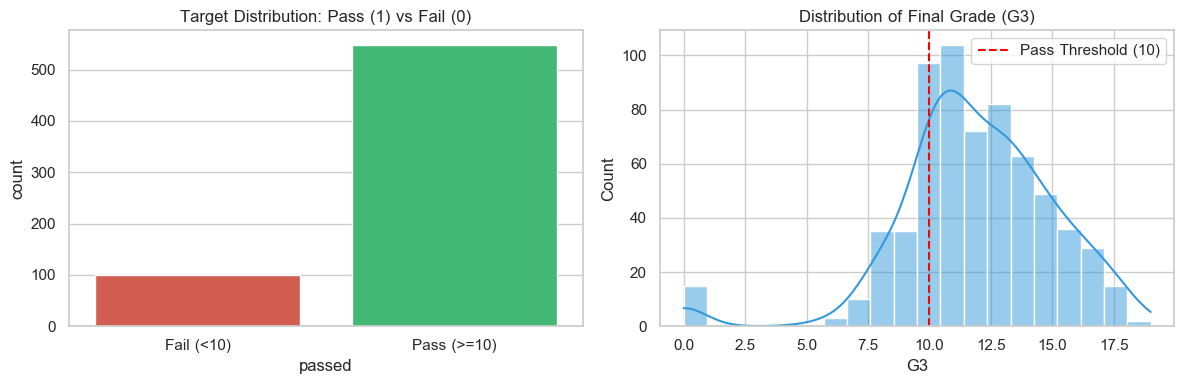

In [9]:
# สร้างคอลัมน์ passed
df['passed'] = (df['G3'] >= 10).astype(int)

# สรุปจำนวนและสัดส่วน
pass_counts = df['passed'].value_counts()
pass_props = df['passed'].value_counts(normalize=True) * 100

print(f"🟢 สอบผ่าน (Pass - 1)  : {pass_counts[1]} คน ({pass_props[1]:.2f}%)")
print(f"🔴 สอบไม่ผ่าน (Fail - 0): {pass_counts[0]} คน ({pass_props[0]:.2f}%)")

# พล็อตดูกราฟสัดส่วน Imbalanced Data
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.countplot(x='passed', data=df, palette=['#e74c3c', '#2ecc71'], ax=axes[0])
axes[0].set_title('Target Distribution: Pass (1) vs Fail (0)')
axes[0].set_xticklabels(['Fail (<10)', 'Pass (>=10)'])

sns.histplot(df['G3'], bins=20, kde=True, color='#3498db', ax=axes[1])
axes[1].axvline(10, color='red', linestyle='--', label='Pass Threshold (10)')
axes[1].set_title('Distribution of Final Grade (G3)')
axes[1].legend()
plt.tight_layout()
plt.show()


## 5. ขั้นตอนที่ 4: การวิเคราะห์ความสัมพันธ์สองตัวแปร (Bivariate Analysis - บทที่ 3.2 ขั้นที่ 4)


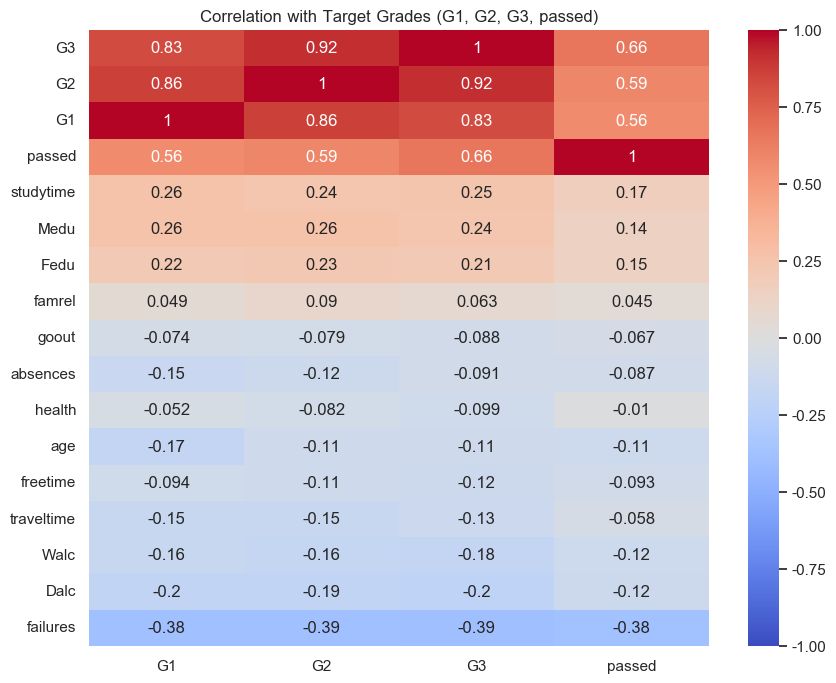

In [10]:
# 5.1 วิเคราะห์ Correlation Matrix
plt.figure(figsize=(10, 8))
numeric_cols = df.select_dtypes(include=[np.number]).columns
corr = df[numeric_cols].corr()
sns.heatmap(corr[['G1', 'G2', 'G3', 'passed']].sort_values(by='G3', ascending=False), 
            annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation with Target Grades (G1, G2, G3, passed)')
plt.show()


#### ⚠️ ข้อสรุปเรื่อง Data Leakage (ตามโจทย์ข้อ 4):
สังเกตว่า $G1$ มี Correlation กับ $G3$ สูงถึง 0.83 และ $G2$ สูงถึง 0.92  
**ข้อตกลง:** เราจะตัด $G1, G2, G3$ ทิ้ง เพื่อบังคับให้โมเดลทำนายจากพฤติกรรม สภาพครอบครัว และการขาดเรียนล้วนๆ เป็นระบบเตือนภัยล่วงหน้า (Early Warning System) ตั้งแต่วันเปิดเทอม


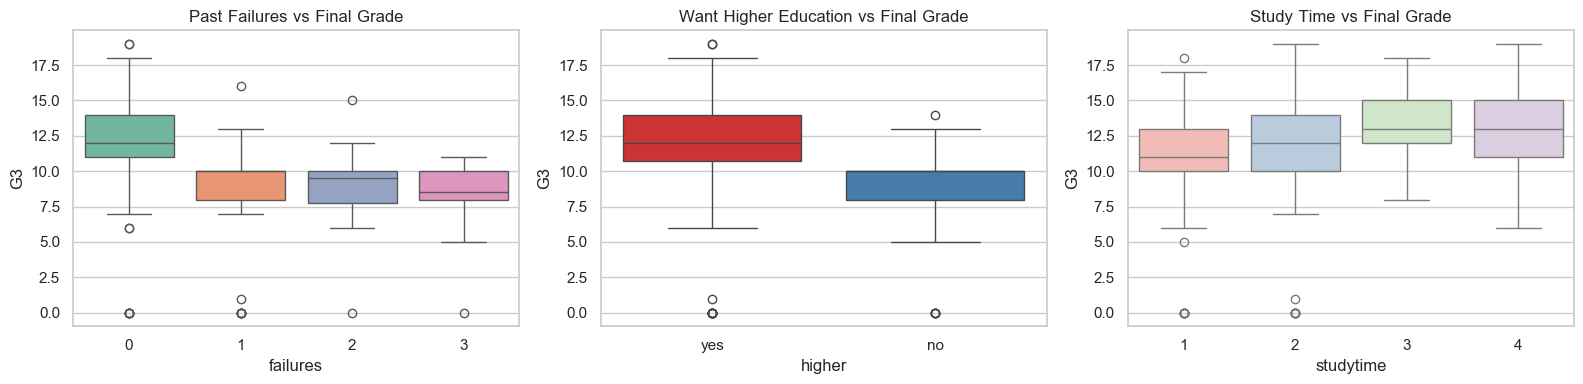

In [11]:
# 5.2 พล็อต Boxplot เปรียบเทียบพฤติกรรมสำคัญกับเกรด G3
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

sns.boxplot(x='failures', y='G3', data=df, palette='Set2', ax=axes[0])
axes[0].set_title('Past Failures vs Final Grade')

sns.boxplot(x='higher', y='G3', data=df, palette='Set1', ax=axes[1])
axes[1].set_title('Want Higher Education vs Final Grade')

sns.boxplot(x='studytime', y='G3', data=df, palette='Pastel1', ax=axes[2])
axes[2].set_title('Study Time vs Final Grade')

plt.tight_layout()
plt.show()


## 6. ขั้นตอนที่ 5: การเตรียมคุณลักษณะและการแบ่งชุดข้อมูล (Feature Engineering & Splitting - บทที่ 2.7)


In [12]:
# 1. แยก Features (X) และ Target (y) พร้อมตัด G1, G2, G3
X_raw = df.drop(columns=['G1', 'G2', 'G3', 'passed'])
y = df['passed']

# 2. ทำ One-Hot Encoding สำหรับตัวแปรประเภท Categorical
X = pd.get_dummies(X_raw, drop_first=True)
print(f"⚙️ จำนวน Features หลังทำ One-Hot Encoding: {X.shape[1]} ตัวแปร")

# 3. สุ่มแบ่งชุดข้อมูล Train/Test (80:20) ด้วย Stratified Sampling (บทที่ 2.7.3)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"📦 ชุดฝึกสอน (Train Set): {X_train.shape[0]} ตัวอย่าง (ผ่าน {sum(y_train==1)}, ตก {sum(y_train==0)})")
print(f"📦 ชุดทดสอบ (Test Set) : {X_test.shape[0]} ตัวอย่าง (ผ่าน {sum(y_test==1)}, ตก {sum(y_test==0)})")

# 4. บันทึกชุดข้อมูลพร้อมใช้ไปยังโฟลเดอร์ data/processed/
train_data = pd.concat([X_train, y_train], axis=1)
test_data = pd.concat([X_test, y_test], axis=1)

train_data.to_csv('../data/processed/train.csv', index=False)
test_data.to_csv('../data/processed/test.csv', index=False)
print("💾 บันทึก train.csv และ test.csv สำเร็จ พร้อมสำหรับสร้างโมเดลในสมุดบันทึกถัดไป!")


⚙️ จำนวน Features หลังทำ One-Hot Encoding: 39 ตัวแปร
📦 ชุดฝึกสอน (Train Set): 519 ตัวอย่าง (ผ่าน 439, ตก 80)
📦 ชุดทดสอบ (Test Set) : 130 ตัวอย่าง (ผ่าน 110, ตก 20)
💾 บันทึก train.csv และ test.csv สำเร็จ พร้อมสำหรับสร้างโมเดลในสมุดบันทึกถัดไป!
